In [6]:
# Cell 1: Setup & Robust Data Loading
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Look for data in current folder OR parent folder
file_name = 'puerto_rico_birth_statistics_2010_2024.csv'
path = file_name if os.path.exists(file_name) else f"../{file_name}"

if os.path.exists(path):
    df = pd.read_csv(path)
    print(f"✅ Data loaded successfully from: {path}")
else:
    print(f"❌ Error: {file_name} not found in current or parent directory.")

df.head()

✅ Data loaded successfully from: ../puerto_rico_birth_statistics_2010_2024.csv


,year,municipio,geoid,total_population,total_births_est,crude_birth_rate
0,2010,Adjuntas Municipio,72001,19541.0,200.0,10.23
1,2010,Aguada Municipio,72003,42232.0,367.0,8.69
2,2010,Aguadilla Municipio,72005,61965.0,633.0,10.22
3,2010,Aguas Buenas Municipio,72007,28827.0,164.0,5.69
4,2010,Aibonito Municipio,72009,26161.0,266.0,10.17


🇵🇷 Island-Wide Birth Statistics (2010 vs 2024):
2010 Rate: 11.48 per 1,000
2024 Rate: 6.77 per 1,000
📉 Total Decline: -41.0%


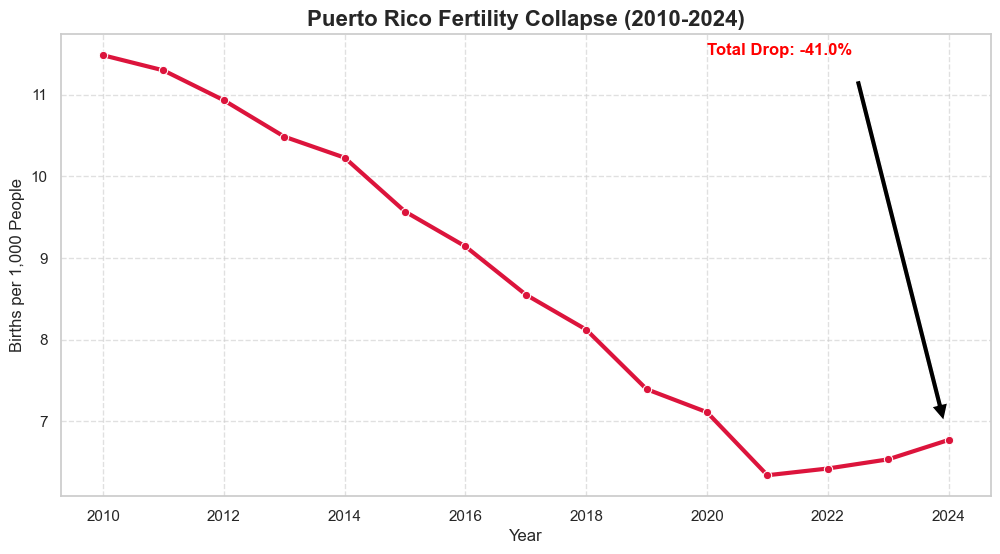

In [7]:
# Cell 2: Aggregate to Island-Wide Totals
# We sum the raw counts first to get the true island-wide rate
island_trend = df.groupby('year')[['total_population', 'total_births_est']].sum().reset_index()

# Calculate the Island-Wide Crude Birth Rate
# Formula: (Total Births / Total Population) * 1,000
island_trend['island_birth_rate'] = (island_trend['total_births_est'] / island_trend['total_population']) * 1000

print("🇵🇷 Island-Wide Birth Statistics (2010 vs 2024):")
start_row = island_trend.iloc[0]
end_row = island_trend.iloc[-1]

print(f"2010 Rate: {start_row['island_birth_rate']:.2f} per 1,000")
print(f"2024 Rate: {end_row['island_birth_rate']:.2f} per 1,000")

# Calculate Total Percentage Drop
total_drop = ((end_row['island_birth_rate'] - start_row['island_birth_rate']) / start_row['island_birth_rate']) * 100
print(f"📉 Total Decline: {total_drop:.1f}%")

# Plot the Island-Wide Trend
plt.figure(figsize=(12, 6))
sns.lineplot(data=island_trend, x='year', y='island_birth_rate', marker='o', linewidth=3, color='crimson')

plt.title('Puerto Rico Fertility Collapse (2010-2024)', fontsize=16, fontweight='bold')
plt.ylabel('Births per 1,000 People', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)

# Add Annotation
plt.annotate(f"Total Drop: {total_drop:.1f}%", 
             xy=(2024, end_row['island_birth_rate']), 
             xytext=(2020, start_row['island_birth_rate']),
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=12, color='red', fontweight='bold')

plt.show()

📉 Top 10 Municipalities with Biggest Birth Rate Decline:


,Rate_2010,Rate_2024,Pct_Change
municipio,,,
Maricao Municipio,6.57,0.00,-100.000000
Vieques Municipio,15.25,0.00,-100.000000
Arroyo Municipio,9.95,0.00,-100.000000
Añasco Municipio,5.95,0.00,-100.000000
Aguada Municipio,8.69,1.24,-85.730725
Guánica Municipio,9.80,1.48,-84.897959
Barceloneta Municipio,15.59,3.69,-76.330981
Las Marías Municipio,9.26,2.52,-72.786177
Salinas Municipio,9.18,2.63,-71.350763



📈 Municipalities with Least Decline (or Growth):


,Rate_2010,Rate_2024,Pct_Change
municipio,,,
San Sebastián Municipio,7.70,9.85,27.922078
Juana Díaz Municipio,10.23,14.52,41.935484
Ceiba Municipio,5.24,9.19,75.381679
Culebra Municipio,7.74,14.42,86.304910
Corozal Municipio,6.35,20.44,221.889764


/var/folders/ym/b3bz6k_51xx92cl9hxg3l4vr0000gn/T/ipykernel_47990/217190699.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_decline, x='Pct_Change', y='municipio', palette='Reds_r')


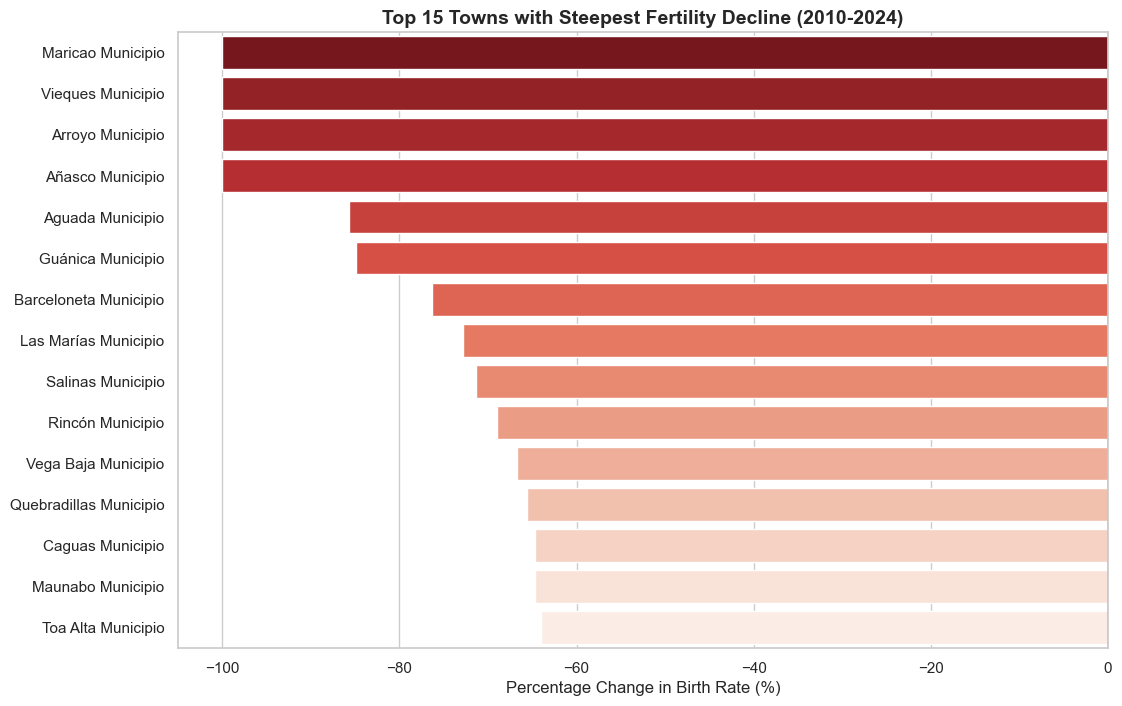

In [8]:
# Cell 3: Analyze Change by Municipality (2010 vs 2024)

# Pivot data to have years as columns for easy math
pivot = df.pivot(index='municipio', columns='year', values='crude_birth_rate')

# Create a DataFrame to store the analysis
muni_analysis = pd.DataFrame()
muni_analysis['Rate_2010'] = pivot[2010]
muni_analysis['Rate_2024'] = pivot[2024]

# Calculate Percent Change Formula: ((New - Old) / Old) * 100
muni_analysis['Pct_Change'] = ((muni_analysis['Rate_2024'] - muni_analysis['Rate_2010']) / muni_analysis['Rate_2010']) * 100

# Sort: Biggest Drops First
muni_analysis = muni_analysis.sort_values('Pct_Change')

print("📉 Top 10 Municipalities with Biggest Birth Rate Decline:")
display(muni_analysis.head(10))

print("\n📈 Municipalities with Least Decline (or Growth):")
display(muni_analysis.tail(5))

# Visualize Top 15 Declines
top_decline = muni_analysis.head(15).reset_index()

plt.figure(figsize=(12, 8))
sns.barplot(data=top_decline, x='Pct_Change', y='municipio', palette='Reds_r')
plt.title('Top 15 Towns with Steepest Fertility Decline (2010-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Percentage Change in Birth Rate (%)')
plt.ylabel(None)
plt.axvline(0, color='black', linewidth=1)
plt.show()

# 📝 Project Analysis: The Fertility Collapse & Data Anomalies

## 1. Island-Wide Demographic "Winter"
The integrated analysis for the entire island reveals a significant structural shift. In 2010, the island-wide Crude Birth Rate (CBR) stood at **11.48**; by 2024, it has plummeted to **6.77**.
* **The Math:** This represents a **41.0% decline** in fertility in just 14 years.
* **Interpretation:** Puerto Rico has moved beyond a "slow growth" phase into a state of "natural decrease." This means that even without further migration, the population will continue to age and shrink because the number of new births is no longer sufficient to replace the aging population.

## 2. Analyzing the "Zero" Data Municipalities
The analysis identified four municipalities reporting **0.0 total births** in the 2024 dataset: **Arroyo, Añasco, Maricao, and Vieques**.

* **Why these zeros occur:** While a true zero birth rate is unlikely in towns of this size (e.g., Añasco has ~25,000 residents), these values occur in the Census ACS estimates due to the **Margin of Error (MOE)**. In towns with extreme out-migration, the density of the "Women 15-50" demographic becomes so low that the sampling survey may fail to capture a birth event within its specific sample group.
* **The "Ghost Town" Indicator:** These zeros serve as a **Demographic Red Flag**. They qualitatively indicate that the reproductive base in these specific towns has reached a "critical minimum," making natural recovery nearly impossible without significant policy intervention.

## 3. Strategic Conclusion for the Planning Board
The birth rate collapse is the primary driver behind the current crisis in school closures and the strain on the healthcare system.
* **Consolidation:** The data justifies a move away from building new child-centric infrastructure in high-decline zones.
* **The "Care Crisis":** As the birth rate falls, the "Support Ratio" (the number of young people available to care for the elderly) is breaking down. This provides the mathematical evidence needed for the proposal to prioritize elderly-care infrastructure over traditional growth-focused urban planning.